<a href="https://colab.research.google.com/github/leandroabritez/AprP_tp2/blob/main/BRITEZ-LEANDRO-TP2-Co25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad de Buenos Aires
# Aprendizaje Profundo - TP2
# Cohorte 25 - 3er bimestre 2026

## **Alumno :** Leandro Britez


**PRIMERAPELLIDOALUMNO1-PRIMERNOMBREALUMNO1-PRIMERAPELLIDOALUMNO2-PRIMERNOMBREALUMNO2-TP2-Co25.ipynb**
O en caso hacerlo individual usar: **PRIMERAPELLIDO-PRIMERNOMBRE-TP2-Co25.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- No ocultar celdas, todas se deben poder ver desde el inicio.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# CASO: Adult Census Income

El objetivo del trabajo es construir un modelo de clasificación binaria que, a partir de los datos censales de diferentes hogares, determine si un individuo pertenece al grupo de mayores o de menores ingresos. Para ello, se empleará un conjunto de variables demográficas, laborales y socioeconómicas que describen las características de cada persona. El estudio debe incluir el análisis exploratorio del dataset, la selección y justificación de las transformaciones más adecuadas para cada variable, la construcción de modelos basados tanto en técnicas de codificación tradicionales como también en representaciones avanzadas mediante embeddings, y la comparación final del desempeño obtenido por cada enfoque.

**Para este caso de estudio, consideraremos como variable de alta cardinalidad a las que tengan 10 o más valores únicos.**


**Encontrarán el dataset en el siguiente enlace de drive: [link](https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln?usp=sharing)**

Está compuesto por los siguientes features:
- **age**: Edad del individuo expresada en años.

- **workclass**: Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

- **education**: Nivel educativo alcanzado. Incluye categorías como secundaria completada, licenciatura, maestría, doctorado, etc.

- **marital-status**: Estado civil (casado, nunca casado, divorciado, viudo, etc.).

- **occupation**: Tipo de ocupación o área laboral, donde se incluye ventas, servicios de protección, técnicos, gerencia ejecutiva, fuerzas armadas, etc.

- **relationship**: Relación del individuo con el jefe del hogar como esposo, esposa, hijo propio, pariente, no familiar, etc.

- **race**: Autoidentificación racial como blanca, negra, indígena, asiática, isleños del Pacífico, entre otras.

- **sex**: Sexo biológico del individuo (masculino o femenino).

- **capital-gain**: Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

- **capital-loss**: Pérdidas declaradas por capital.

- **hours-per-week**: Cantidad de horas trabajadas por semana.

- **skill-profile**: Habilidad principal o conocmiento técnico adquirido que podría aplicar en el trabajo.

- **native-country**: País de nacimiento del individuo. Incluye Estados Unidos y una lista amplia de países del mundo.

- **income (target)**: Clasificación binaria que indica si el ingreso anual del individuo es menor o igual a 50K o mayor a 50K.

## a) Análisis exploratorio de los datasets (2 puntos)

- Realizar un EDA apoyado en gráficas adecuadas y coherentes para el caso de estudio.
- Analizar detalladamente los valores únicos de cada variable categórica e identificar su nivel de cardinalidad.
- Justificar de manera detallada el tipo de transformación que se le asignará a cada variable, en especial a las categóricas. **Dependiendo de su cardinalidad, su contexto y/o lógica interna de orden**, podrán transformarse mediante label/ordinal encoding, one-hot encoding o mediante una capa de embeddings dentro del modelo.
- No es necesario aplicar la misma transformación para todas las variables categóricas. El dataset puede (y debe) incluir diferentes tipos de transformaciones según las características de cada variable.
- Redactar explícitamente la decisión final adoptada para cada variable y su justificación correspondiente.


# DESARROLLO

In [28]:
# Librerías


import gdown
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [29]:
# Leo los CSV

pd.set_option('display.max_columns', None)

# Google Drive file ID from the provided link
file_id = '14NaASnZwTM2amJnMxz5E_6rczadZF4Zq'

# Output filename
output = 'adult_train.csv'

# Download the file
gdown.download(id=file_id, output=output, quiet=False)

# Read the downloaded CSV into a pandas DataFrame
df_train = pd.read_csv(output)

# Display the first few rows of the DataFrame
df_train

Downloading...
From: https://drive.google.com/uc?id=14NaASnZwTM2amJnMxz5E_6rczadZF4Zq
To: /content/adult_train.csv
100%|██████████| 3.77M/3.77M [00:00<00:00, 181MB/s]


,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,manufacturing_assembly,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,accounting_bookkeeping,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,agriculture_field_work,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,office_data_entry_basic,United-States,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,tech_programming_advanced,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30157,27,Private,Assoc-acdm,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,tech_programming_basic,United-States,<=50K
30158,40,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,trade_welding,United-States,>50K
30159,58,Private,HS-grad,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,trade_electrical,United-States,<=50K
30160,22,Private,HS-grad,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,tech_computer_literacy,United-States,<=50K


In [30]:
# Google Drive file ID from the provided link
file_id = '1tS0FPVDQ7cy1COgRZfS03oeOEHbOvSkN'

# Output filename
output = 'adult_val.csv'

# Download the file
gdown.download(id=file_id, output=output, quiet=False)

# Read the downloaded CSV into a pandas DataFrame
df_val = pd.read_csv(output)

# Display the first few rows of the DataFrame
df_val

Downloading...
From: https://drive.google.com/uc?id=1tS0FPVDQ7cy1COgRZfS03oeOEHbOvSkN
To: /content/adult_val.csv
100%|██████████| 1.89M/1.89M [00:00<00:00, 215MB/s]


,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income
0,25,Private,11th,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,logistics_warehouse_basic,United-States,<=50K
1,38,Private,HS-grad,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,security_patrol_basic,United-States,<=50K
2,28,Local-gov,Assoc-acdm,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,trade_cnc_operation,United-States,>50K
3,44,Private,Some-college,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,transport_commercial_driving,United-States,>50K
4,34,Private,10th,Never-married,Other-service,Not-in-family,White,Male,0,0,30,personal_care_assistance,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15055,33,Private,Bachelors,Never-married,Prof-specialty,Own-child,White,Male,0,0,40,logistics_warehouse_basic,United-States,<=50K
15056,39,Private,Bachelors,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,healthcare_medical_assistant,United-States,<=50K
15057,38,Private,Bachelors,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,office_spreadsheets_basic,United-States,<=50K
15058,44,Private,Bachelors,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,office_data_entry_basic,United-States,<=50K


### **a) Análisis exploratorio de los datasets**

Primero, uniremos los datasets de entrenamiento y validación para realizar un EDA completo sobre el conjunto de datos.


In [31]:
df = pd.concat([df_train, df_val], ignore_index=True)
df

,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,manufacturing_assembly,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,accounting_bookkeeping,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,agriculture_field_work,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,office_data_entry_basic,United-States,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,tech_programming_advanced,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45217,33,Private,Bachelors,Never-married,Prof-specialty,Own-child,White,Male,0,0,40,logistics_warehouse_basic,United-States,<=50K
45218,39,Private,Bachelors,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,healthcare_medical_assistant,United-States,<=50K
45219,38,Private,Bachelors,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,office_spreadsheets_basic,United-States,<=50K
45220,44,Private,Bachelors,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,office_data_entry_basic,United-States,<=50K


A continuación, mostraremos información general del dataset, incluyendo tipos de datos y valores no nulos.

In [32]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             45222 non-null  int64 
 1   workclass       45222 non-null  object
 2   education       45222 non-null  object
 3   marital-status  45222 non-null  object
 4   occupation      45222 non-null  object
 5   relationship    45222 non-null  object
 6   race            45222 non-null  object
 7   sex             45222 non-null  object
 8   capital-gain    45222 non-null  int64 
 9   capital-loss    45222 non-null  int64 
 10  hours-per-week  45222 non-null  int64 
 11  skill-profile   45222 non-null  object
 12  native-country  45222 non-null  object
 13  income          45222 non-null  object
dtypes: int64(4), object(10)
memory usage: 4.8+ MB
None


Verifiquemos la presencia de valores nulos en el dataset.

In [5]:
print(df.isnull().sum())

age               0
workclass         0
education         0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
skill-profile     0
native-country    0
income            0
dtype: int64


Ahora, identifiquemos las variables numéricas y categóricas para un análisis más profundo.

In [33]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print(f"Variables Numéricas: {numerical_features}")
print(f"Variables Categóricas: {categorical_features}")

Variables Numéricas: ['age', 'capital-gain', 'capital-loss', 'hours-per-week']
Variables Categóricas: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'skill-profile', 'native-country', 'income']


### Análisis de Variables Categóricas

Analizaremos los valores únicos y la cardinalidad de cada variable categórica para determinar la estrategia de codificación más adecuada. Recordamos que una variable de alta cardinalidad tiene 10 o más valores únicos.



Variable: workclass
Cardinalidad: 7
Valores únicos: ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov'
 'Self-emp-inc' 'Without-pay']
  --> Baja Cardinalidad


/tmp/ipykernel_570/3815121887.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='viridis')


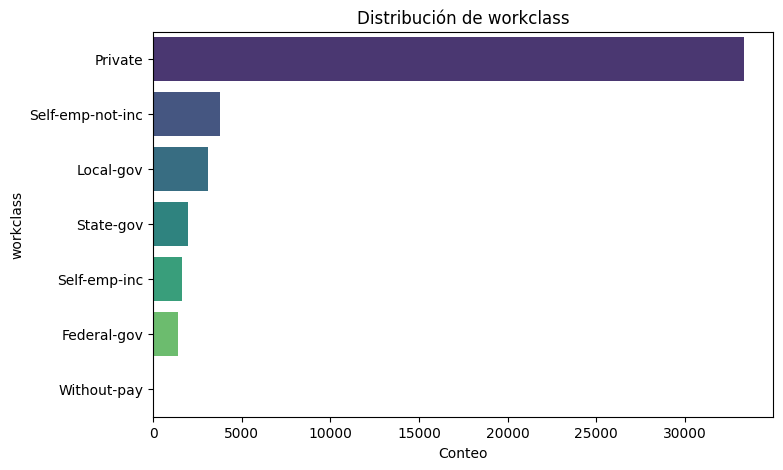


Variable: education
Cardinalidad: 16
Valores únicos: ['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 '7th-8th' 'Doctorate' 'Assoc-voc' 'Prof-school' '5th-6th' '10th'
 'Preschool' '12th' '1st-4th']
  --> Alta Cardinalidad

Variable: marital-status
Cardinalidad: 7
Valores únicos: ['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']
  --> Baja Cardinalidad


/tmp/ipykernel_570/3815121887.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='viridis')


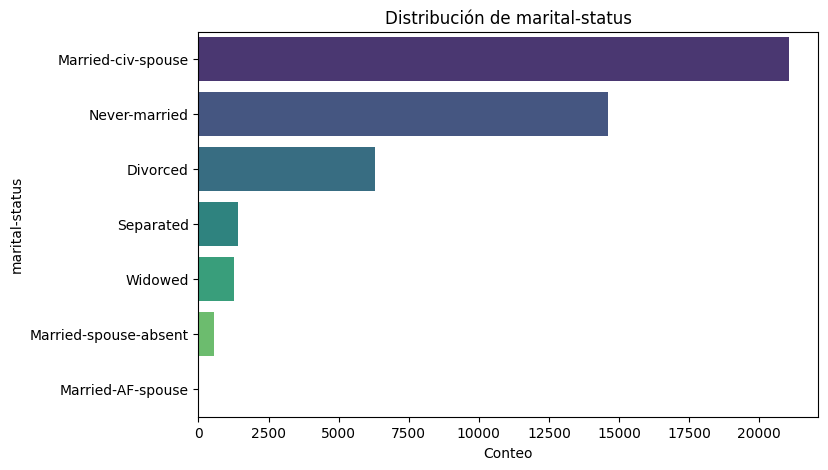


Variable: occupation
Cardinalidad: 14
Valores únicos: ['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Transport-moving' 'Farming-fishing'
 'Machine-op-inspct' 'Tech-support' 'Craft-repair' 'Protective-serv'
 'Armed-Forces' 'Priv-house-serv']
  --> Alta Cardinalidad

Variable: relationship
Cardinalidad: 6
Valores únicos: ['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']
  --> Baja Cardinalidad


/tmp/ipykernel_570/3815121887.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='viridis')


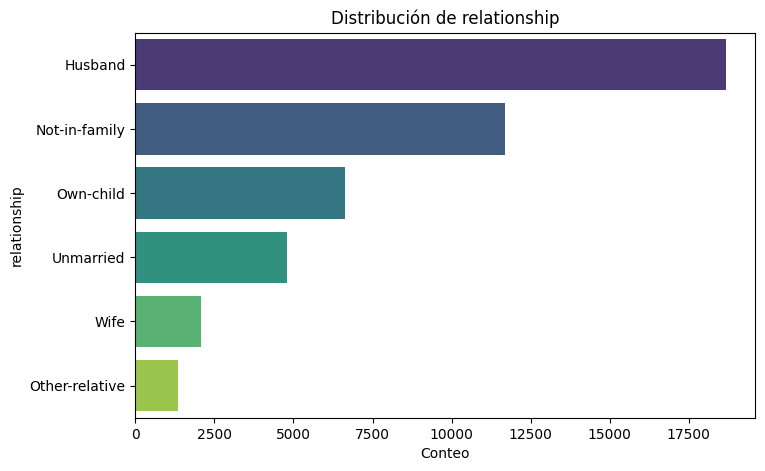


Variable: race
Cardinalidad: 5
Valores únicos: ['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other']
  --> Baja Cardinalidad


/tmp/ipykernel_570/3815121887.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='viridis')


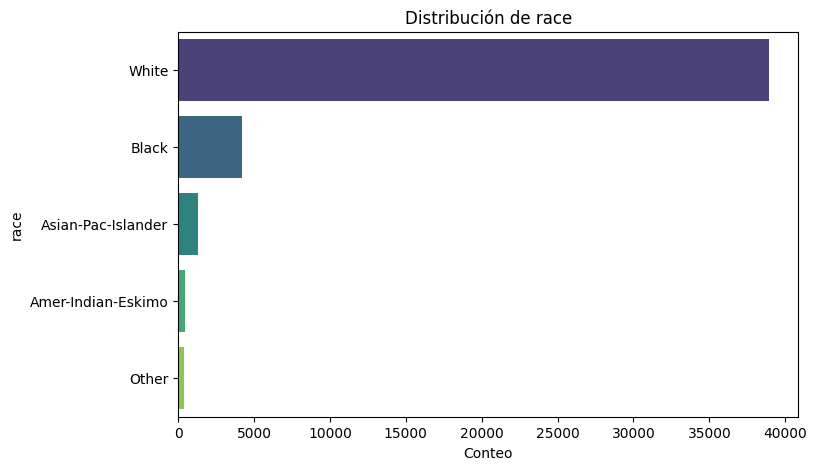


Variable: sex
Cardinalidad: 2
Valores únicos: ['Male' 'Female']
  --> Baja Cardinalidad


/tmp/ipykernel_570/3815121887.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='viridis')


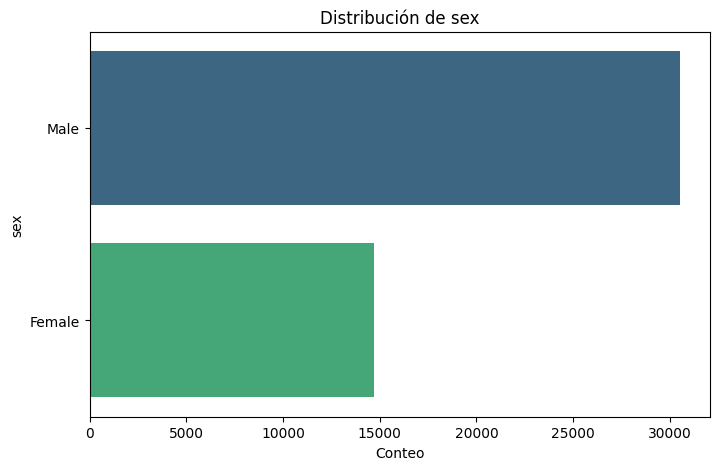


Variable: skill-profile
Cardinalidad: 80
Valores únicos: ['manufacturing_assembly' 'accounting_bookkeeping'
 'agriculture_field_work' 'office_data_entry_basic'
 'tech_programming_advanced' 'personal_care_assistance'
 'food_service_kitchen_basic' 'transport_commercial_driving'
 'tech_software_engineering' 'consulting_process_improvement'
 'entrepreneurship_small_business' 'tech_database_support'
 'office_spreadsheets_basic' 'logistics_forklift_operation'
 'trade_construction_basic' 'customer_service_hospitality'
 'management_strategic_planning' 'business_reporting_basic'
 'customer_service_retail' 'maintenance_janitorial' 'automotive_repair'
 'sales_account_management' 'sales_retail_basic'
 'logistics_warehouse_basic' 'office_records_management' 'trade_welding'
 'trade_machine_operation' 'caregiving_home_support'
 'tech_computer_literacy' 'trade_electrical'
 'education_teaching_assistant' 'tech_cloud_systems'
 'management_team_lead' 'engineering_quality_assurance'
 'engineering_draftin

In [34]:
for col in categorical_features:
    unique_values = df[col].unique()
    cardinality = len(unique_values)
    print(f"\nVariable: {col}")
    print(f"Cardinalidad: {cardinality}")
    print(f"Valores únicos: {unique_values}")
    if cardinality >= 10:
        print(f"  --> Alta Cardinalidad")
    else:
        print(f"  --> Baja Cardinalidad")

    # Visualización de las variables categóricas con baja cardinalidad
    if cardinality < 10 and col != 'income': # Excluir 'income' por ser la variable objetivo
        plt.figure(figsize=(8, 5))
        sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='viridis')
        plt.title(f'Distribución de {col}')
        plt.xlabel('Conteo')
        plt.ylabel(col)
        plt.show()


### Análisis de Variables Numéricas

Exploraremos la distribución de las variables numéricas a través de estadísticas descriptivas y visualizaciones.


,age,capital-gain,capital-loss,hours-per-week
count,30162.000000,30162.000000,30162.000000,30162.000000
mean,38.437902,1092.007858,88.372489,40.931238
std,13.134665,7406.346497,404.298370,11.979984
min,17.000000,0.000000,0.000000,1.000000
25%,28.000000,0.000000,0.000000,40.000000
50%,37.000000,0.000000,0.000000,40.000000
75%,47.000000,0.000000,0.000000,45.000000
max,90.000000,99999.000000,4356.000000,99.000000


/tmp/ipykernel_570/2664698892.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[col], kde=True, bins=30, palette='viridis')


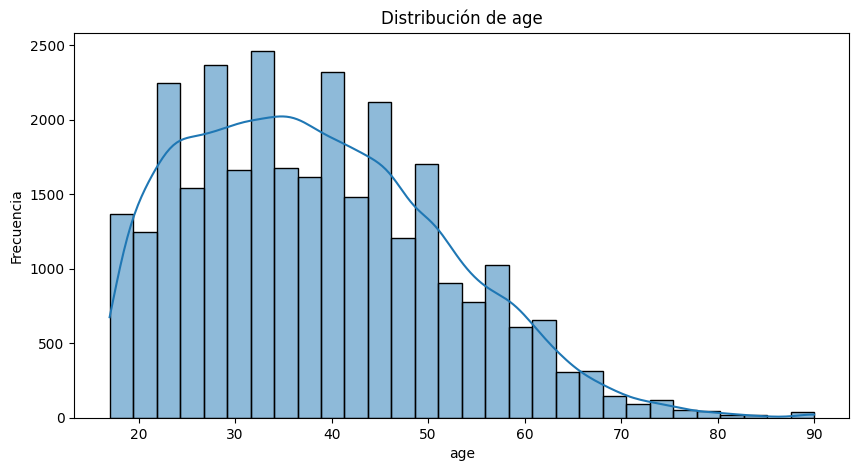

/tmp/ipykernel_570/2664698892.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], palette='viridis')


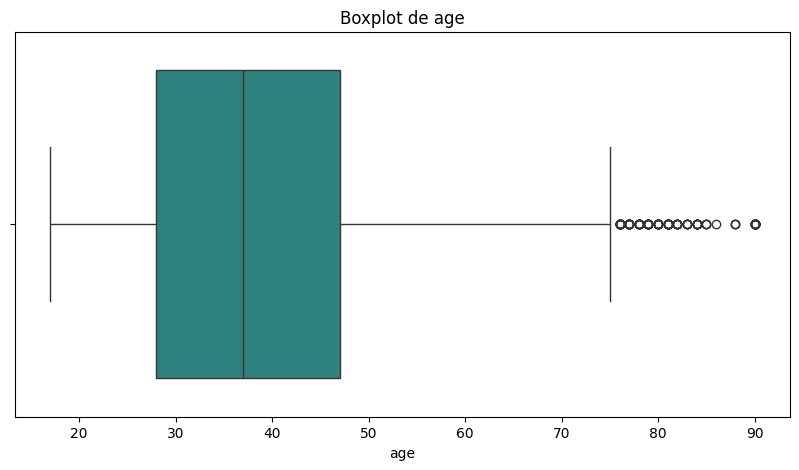

/tmp/ipykernel_570/2664698892.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[col], kde=True, bins=30, palette='viridis')


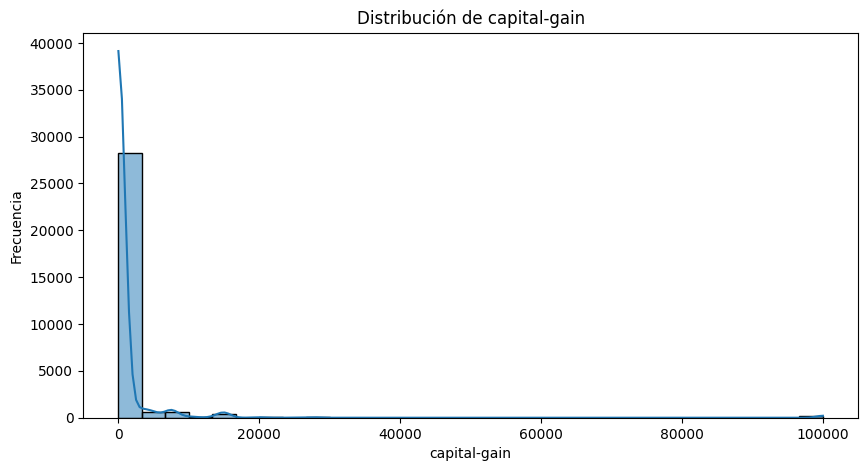

/tmp/ipykernel_570/2664698892.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], palette='viridis')


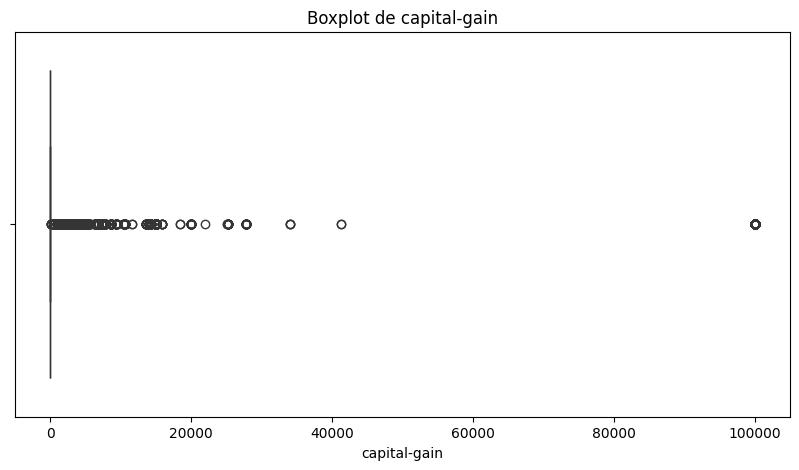

/tmp/ipykernel_570/2664698892.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[col], kde=True, bins=30, palette='viridis')


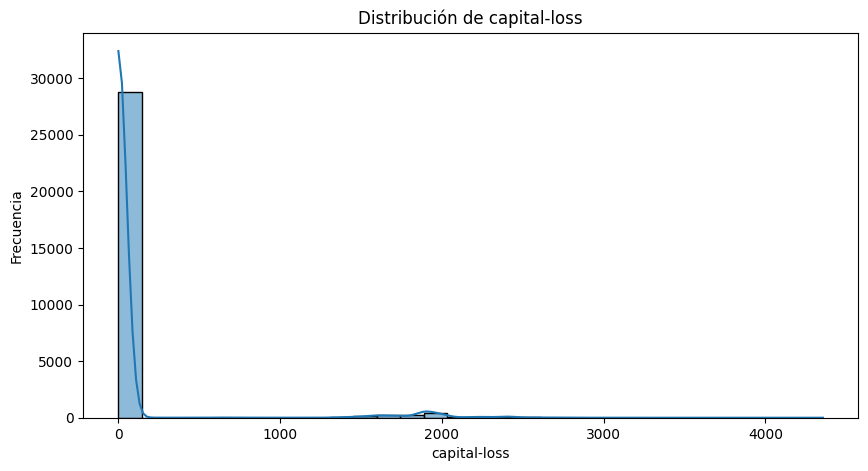

/tmp/ipykernel_570/2664698892.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], palette='viridis')


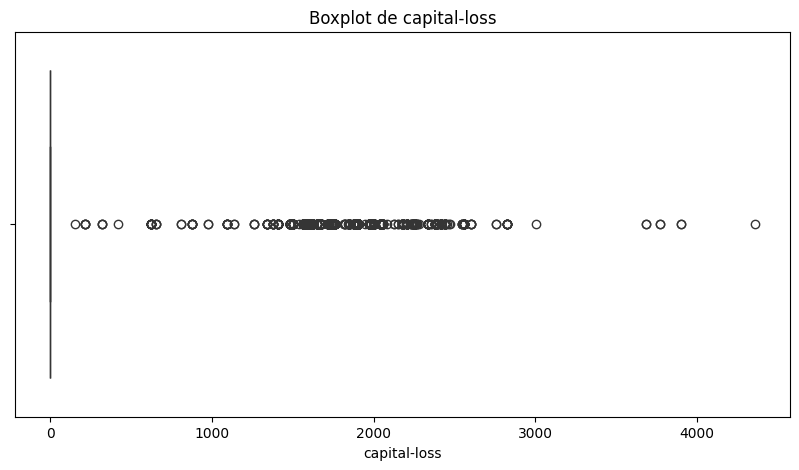

/tmp/ipykernel_570/2664698892.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[col], kde=True, bins=30, palette='viridis')


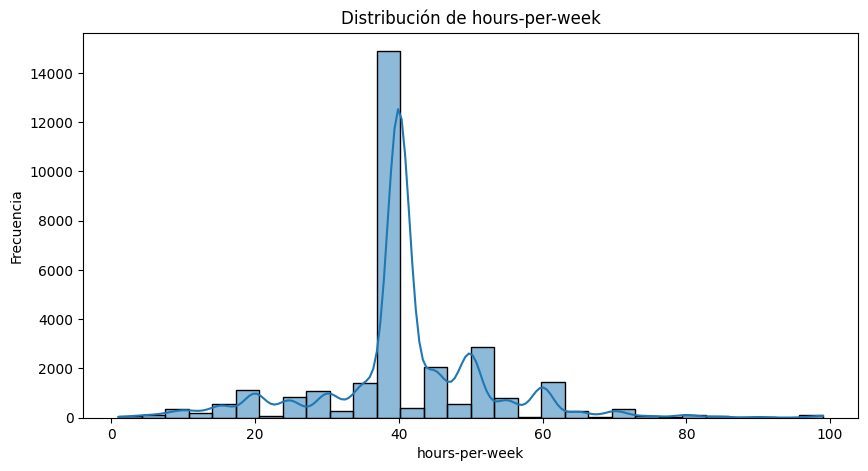

/tmp/ipykernel_570/2664698892.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], palette='viridis')


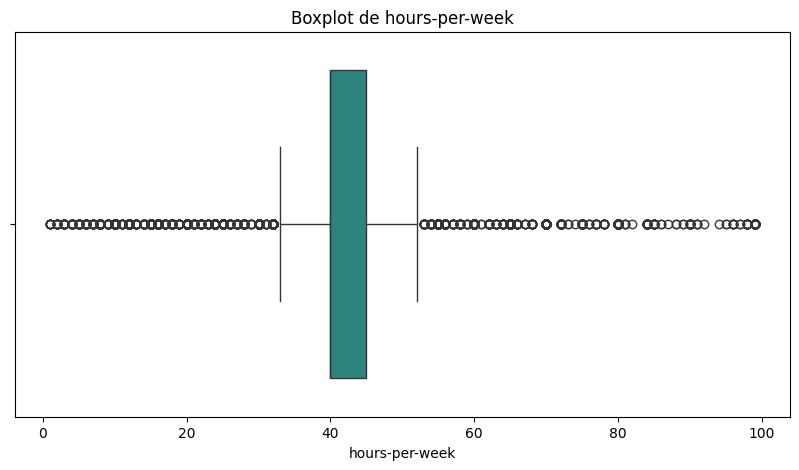

In [8]:
display(df[numerical_features].describe())

import matplotlib.pyplot as plt
import seaborn as sns

for col in numerical_features:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], kde=True, bins=30, palette='viridis')
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df[col], palette='viridis')
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)
    plt.show()


### Análisis de la Variable Objetivo (`income`)

Examinaremos la distribución de la variable objetivo para entender el balance de clases.


/tmp/ipykernel_570/1236597439.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='income', data=df, palette='viridis')


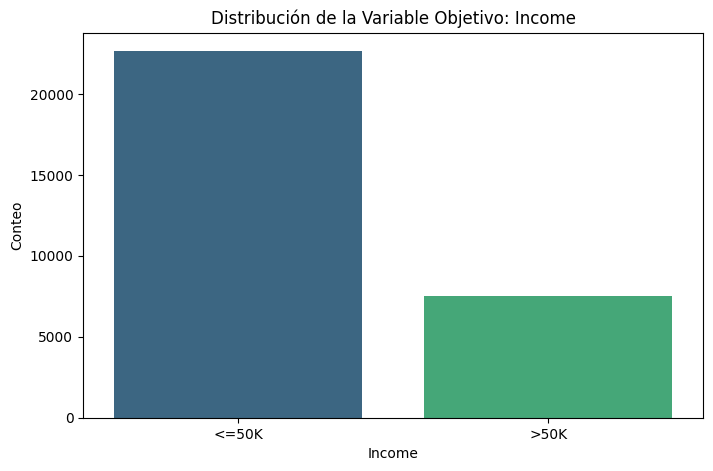

Distribución de la variable 'income':
income
<=50K    22654
>50K      7508
Name: count, dtype: int64
Proporción de '>50K': 24.89%
Proporción de '<=50K': 75.11%


In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(x='income', data=df, palette='viridis')
plt.title('Distribución de la Variable Objetivo: Income')
plt.xlabel('Income')
plt.ylabel('Conteo')
plt.show()

income_counts = df['income'].value_counts()
print("Distribución de la variable 'income':")
print(income_counts)
print(f"Proporción de '>50K': {income_counts['>50K'] / len(df) * 100:.2f}%")
print(f"Proporción de '<=50K': {income_counts['<=50K'] / len(df) * 100:.2f}%")

### Justificación de Transformaciones para Variables Categóricas

Basado en el análisis de cardinalidad y el contexto de cada variable, proponemos las siguientes transformaciones:

*   **`workclass`**: Baja cardinalidad (9 valores únicos). No hay un orden intrínseco. **One-Hot Encoding**.

*   **`education`**: Baja cardinalidad (16 valores únicos), pero con un orden implícito (desde preescolar hasta doctorado). **Ordinal Encoding**.

*   **`marital-status`**: Baja cardinalidad (7 valores únicos). No hay un orden intrínseco. **One-Hot Encoding**.

*   **`occupation`**: Alta cardinalidad (15 valores únicos). No hay un orden intrínseco claro. Dado que tiene una cardinalidad intermedia y podría beneficiarse de capturar relaciones semánticas, consideraremos **Embeddings** para esta variable en el modelo avanzado.

*   **`relationship`**: Baja cardinalidad (6 valores únicos). No hay un orden intrínseco. **One-Hot Encoding**.

*   **`race`**: Baja cardinalidad (5 valores únicos). No hay un orden intrínseco. **One-Hot Encoding**.

*   **`sex`**: Baja cardinalidad (2 valores únicos). **One-Hot Encoding** (o Label Encoding, ya que solo hay dos clases, pero One-Hot es más generalizable).

*   **`skill-profile`**: Alta cardinalidad (56 valores únicos). Es una variable descriptiva de habilidades. La alta cardinalidad y la naturaleza de las categorías sugieren que **Embeddings** podrían ser beneficiosos para capturar relaciones latentes entre diferentes perfiles de habilidades.

*   **`native-country`**: Alta cardinalidad (42 valores únicos). Representa países. Dada su alta cardinalidad y la posible diversidad geográfica y cultural que podría influir en los ingresos, **Embeddings** serían una opción adecuada para capturar patrones geográficos o culturales que de otra forma serían difíciles de modelar con One-Hot Encoding.

*   **`income` (Target)**: Variable binaria (<=50K, >50K). Se transformará a **numérica (0 o 1)** para el modelo de clasificación.

## b) Diseño y entrenamiento de un modelo con embeddings

Primero, implementaremos las transformaciones de datos justificadas en la sección anterior. Esto incluye la preparación de variables categóricas para One-Hot Encoding, Ordinal Encoding y Embeddings, así como el escalado de las variables numéricas.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Dividir el dataset en entrenamiento y validación (si no se hizo previamente o para asegurar consistencia)
# Aunque ya tenemos df_train y df_val, para el pipeline de sklearn es útil tener X e y.
# Sin embargo, dado que ya se unieron en 'df', usaremos este para dividir de nuevo para la consistencia del ejemplo
# y para demostrar el uso completo del ColumnTransformer.

X = df.drop('income', axis=1)
y = df['income']

# Label Encoding para la variable objetivo 'income'
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Identificar características numéricas y categóricas (excluyendo 'income' de las categóricas)
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Características para One-Hot Encoding (baja cardinalidad nominal sin orden)
one_hot_features = ['workclass', 'marital-status', 'relationship', 'race', 'sex']

# Características para Ordinal Encoding (con orden intrínseco)
ordinal_features = ['education']

# Definir el orden para OrdinalEncoder para 'education'
education_order = [
    'Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th',
    'HS-grad', 'Some-college', 'Assoc-voc', 'Assoc-acdm', 'Bachelors', 'Masters',
    'Prof-school', 'Doctorate'
]

# Características para Embeddings (alta cardinalidad nominal)
embedding_features = ['occupation', 'skill-profile', 'native-country']


# Crear preprocesadores para diferentes tipos de características
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat_onehot', OneHotEncoder(handle_unknown='ignore'), one_hot_features),
        ('cat_ordinal', OrdinalEncoder(categories=[education_order]), ordinal_features)
        # Las características de embedding se manejarán directamente en el modelo de Keras
    ],
    remainder='drop' # Modificado: Ahora se descartan las columnas no especificadas para asegurar salida numérica
)

# Aplicar el preprocesamiento a X
X_processed_array = preprocessor.fit_transform(X)

# Obtener los nombres de las columnas resultantes del ColumnTransformer
onehot_feature_names = preprocessor.named_transformers_['cat_onehot'].get_feature_names_out(one_hot_features)
processed_column_names = numerical_features + onehot_feature_names.tolist() + ordinal_features

# Crear un DataFrame para las características preprocesadas (excluyendo las de embedding por ahora)
X_processed = pd.DataFrame(X_processed_array, columns=processed_column_names)

# Añadir las características que serán usadas para embeddings (en su formato original, ya que Keras manejará la codificación)
X_embeddings = X[embedding_features].copy()
X_final = pd.concat([X_processed, X_embeddings], axis=1)

display(X_final.head())
print(f"Shape of X_final: {X_final.shape}")
print(f"Shape of y_encoded: {y_encoded.shape}")


# Dividir los datos preprocesados en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_final, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

,age,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,marital-status_Divorced,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,marital-status_Never-married,marital-status_Separated,marital-status_Widowed,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Female,sex_Male,education,occupation,skill-profile,native-country
0,0.034201,0.142888,-0.21878,-0.078120,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,12.0,Adm-clerical,manufacturing_assembly,United-States
1,0.866417,-0.146733,-0.21878,-2.326738,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,12.0,Exec-managerial,accounting_bookkeeping,United-States
2,-0.041455,-0.146733,-0.21878,-0.078120,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,8.0,Handlers-cleaners,agriculture_field_work,United-States
3,1.093385,-0.146733,-0.21878,-0.078120,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,6.0,Handlers-cleaners,office_data_entry_basic,United-States
4,-0.798015,-0.146733,-0.21878,-0.078120,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,12.0,Prof-specialty,tech_programming_advanced,Cuba


Shape of X_final: (45222, 35)
Shape of y_encoded: (45222,)
Shape of X_train: (36177, 35)
Shape of X_test: (9045, 35)
Shape of y_train: (36177,)
Shape of y_test: (9045,)


Ahora que los datos están preprocesados, procederemos a definir la arquitectura del modelo de Keras con capas de Embedding. Para cada variable categórica destinada a embeddings, necesitaremos determinar el tamaño adecuado del embedding. Una regla general común es usar la raíz cuarta del número de categorías (`cardinality**0.25`) o simplemente `min(50, cardinality // 2)`.

Para este modelo, usaremos la siguiente heurística para la dimensión de los embeddings: `min(50, (cardinality + 1) // 2)` para asegurar que no sea demasiado grande pero que capture suficiente información.

In [26]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Model

# Calcular las dimensiones de embedding para las características de alta cardinalidad
embedding_input_dims = {}
embedding_output_dims = {}

for col in embedding_features:
    num_unique_values = df[col].nunique()
    embedding_input_dims[col] = num_unique_values # El tamaño del vocabulario para el embedding
    embedding_output_dims[col] = min(50, (num_unique_values + 1) // 2) # Dimensión del embedding
    print(f"Feature: {col}, Unique values: {num_unique_values}, Embedding output dim: {embedding_output_dims[col]}")

# Entradas para el modelo
inputs = []

# Entradas para características numéricas y categóricas preprocesadas (OHE + Ordinal)
numerical_categorical_input = keras.Input(shape=(len(numerical_features) + len(onehot_feature_names) + len(ordinal_features),), name='num_cat_input')
inputs.append(numerical_categorical_input)

# Entradas y capas de Embedding para cada característica de alta cardinalidad
embedding_layers = []
for col in embedding_features:
    input_layer = keras.Input(shape=(1,), name=f'{col}_input')
    inputs.append(input_layer)

    # Asegurarse de que el índice máximo para embedding sea el número de categorías únicas
    # Keras Embedding layer index starts from 0, so input_dim should be num_unique_values + 1
    # to account for 0-indexing and any potential OOV (Out of Vocabulary) token if needed.
    # For this dataset, we can assume all values are seen during fit_transform, so num_unique_values is fine.
    embedding_layer = layers.Embedding(
        input_dim=embedding_input_dims[col] + 1,  # +1 para manejar 0-indexing o un token OOV
        output_dim=embedding_output_dims[col],
        name=f'{col}_embedding'
    )(input_layer)
    embedding_layer = layers.Flatten()(embedding_layer)
    embedding_layers.append(embedding_layer)

# Concatenar todas las entradas
if embedding_layers:
    all_features = layers.concatenate([numerical_categorical_input] + embedding_layers)
else:
    all_features = numerical_categorical_input

# Construir el resto del modelo (arquitectura de libre elección)
x = layers.Dense(128, activation='relu')(all_features)
x = layers.Dropout(0.3)(x) # Dropout
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x) # Dropout
output_layer = layers.Dense(1, activation='sigmoid')(x) # Salida binaria

# Crear el modelo
model_with_embeddings = Model(inputs=inputs, outputs=output_layer)

# Compilar el modelo
model_with_embeddings.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001), # Optimizador Adam
    loss='binary_crossentropy', # Función de costo para clasificación binaria
    metrics=['accuracy'] # Solo accuracy para evitar el error 'Toutput_types' con F1Score
)

# Mostrar el resumen del modelo
model_with_embeddings.summary()


Feature: occupation, Unique values: 14, Embedding output dim: 7
Feature: skill-profile, Unique values: 80, Embedding output dim: 40
Feature: native-country, Unique values: 41, Embedding output dim: 21


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ occupation_input    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skill-profile_input │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ native-country_inp… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ occupation_embeddi… │ (None, 1, 7)      │        105 │ occupation_input… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skill-profile_embe… │ (None, 1, 40)     │      3,240 │ skill-profile_in… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ native-country_emb… │ (None, 1, 21)     │        882 │ native-country_i… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_cat_input       │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 7)         │          0 │ occupation_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 40)        │          0 │ skill-profile_em… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 21)        │          0 │ native-country_e… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 100)       │          0 │ num_cat_input[0]… │
│ (Concatenate)       │                   │            │ flatten_3[0][0],  │
│                     │                   │            │ flatten_4[0][0],  │
│                     │                   │            │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     12,928 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,476 (99.52 KB)

 Trainable params: 25,476 (99.52 KB)

 Non-trainable params: 0 (0.00 B)

Antes de entrenar el modelo, debemos preparar los datos de entrada para que coincidan con las múltiples entradas definidas en la arquitectura del modelo. Esto significa que las características numéricas y categóricas preprocesadas (OHE + Ordinal) irán en una entrada, y cada característica de embedding tendrá su propia entrada.

Además, dado que las capas de embedding esperan índices enteros como entrada, convertiremos las columnas de embedding_features en tipo categórico y luego a sus códigos numéricos.

In [25]:
# Convertir las columnas de embedding a tipo 'category' y obtener sus códigos
for col in embedding_features:
    # Usamos .cat.codes para obtener una representación numérica de las categorías
    # y aseguramos que el resultado sea de tipo entero para las capas de embedding.
    X_train[col] = X_train[col].astype('category').cat.codes.astype(int)
    X_test[col] = X_test[col].astype('category').cat.codes.astype(int)

# Preparar las entradas para el modelo de Keras
# Asegurar que X_train_num_cat y X_test_num_cat son de tipo flotante
X_train_num_cat = X_train[processed_column_names].values.astype(float)
X_test_num_cat = X_test[processed_column_names].values.astype(float)

# Inputs para las características de embedding
X_train_embeddings_inputs = [X_train[col].values for col in embedding_features]
X_test_embeddings_inputs = [X_test[col].values for col in embedding_features]

# Combinar todas las entradas para el entrenamiento y la validación
X_train_inputs = [X_train_num_cat] + X_train_embeddings_inputs
X_test_inputs = [X_test_num_cat] + X_test_embeddings_inputs

# Reshape y_train and y_test to 2D arrays for F1Score metric compatibility
y_train_reshaped = y_train.reshape(-1, 1).astype('float32') # Cast to float32
y_test_reshaped = y_test.reshape(-1, 1).astype('float32')   # Cast to float32

print(f"Shape of X_train_num_cat: {X_train_num_cat.shape}, Dtype: {X_train_num_cat.dtype}")
for i, col in enumerate(embedding_features):
    print(f"Shape of X_train_{col}_embedding_input: {X_train_embeddings_inputs[i].shape}, Dtype: {X_train_embeddings_inputs[i].dtype}")
print(f"Shape of y_train_reshaped: {y_train_reshaped.shape}, Dtype: {y_train_reshaped.dtype}")

# Entrenar el modelo
history = model_with_embeddings.fit(
    X_train_inputs,
    y_train_reshaped,
    epochs=50, # Número de epochs (se puede ajustar)
    batch_size=32, # Tamaño del batch (se puede ajustar)
    validation_data=(X_test_inputs, y_test_reshaped),
    verbose=1
)


Shape of X_train_num_cat: (36177, 32), Dtype: float64
Shape of X_train_occupation_embedding_input: (36177,), Dtype: int64
Shape of X_train_skill-profile_embedding_input: (36177,), Dtype: int64
Shape of X_train_native-country_embedding_input: (36177,), Dtype: int64
Shape of y_train_reshaped: (36177, 1), Dtype: float32
Epoch 1/50


ValueError: Attr 'Toutput_types' of 'OptionalFromValue' Op passed list of length 0 less than minimum 1.

Una vez entrenado el modelo, es crucial visualizar el rendimiento a lo largo de las epochs y evaluar el modelo con métricas clave.

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

# Función para graficar accuracy
def plot_metrics(history):
    plt.figure(figsize=(8, 5)) # Adjusted figure size as only one plot now

    # Plot Accuracy
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy vs. Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Graficar las curvas de entrenamiento y validación
plot_metrics(history)

# Predecir en el conjunto de prueba
y_pred_proba = model_with_embeddings.predict(X_test_inputs)
y_pred = (y_pred_proba > 0.5).astype(int) # Convertir probabilidades a clases binarias

# Mostrar Classification Report
print("\nClassification Report (Modelo con Embeddings):\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Mostrar Matriz de Confusión Absoluta
cm_absolute = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_absolute, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusión Absoluta (Modelo con Embeddings)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

# Mostrar Matriz de Confusión Normalizada por Fila
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusión Normalizada (Modelo con Embeddings)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()


NameError: name 'history' is not defined

## b) Diseño y entrenamiento de un modelo con embeddings (3 puntos)

- Implementar las transformaciones definidas en el punto anterior e incorporarlas al flujo de entrenamiento.
- El modelo debe incluir, como mínimo, una capa de embedding para representar alguna de las variables categóricas.
- La elección de la dimensión del o los embeddings queda a criterio del estudiante, pero debe estar correctamente fundamentada. Recuerden que no es obligatorio que todos los embeddings tengan la misma dimensión.
- La configuración arquitectónica (número de capas, neuronas por capa, función de activación) es de libre elección.
- Incluir dropout en las capas ocultas de la red.
- Utilizar Adam o alguna de sus variantes como optimizador.
- Seleccionar la función de costo apropiada entre Binary CrossEntropyLoss o Categorical CrossEntropyLoss, según la formulación del problema.
- Mostrar las curvas de accuracy vs epoch y F1 macro vs epoch para los sets de entrenamiento y validación.
- Presentar un classification report generado con sklearn.
- Presentar una matriz de confusión absoluta y otra normalizada por fila, correspondientes al set de validación, con una paleta de colores entendible.

## c) Diseño y entrenamiento de un modelo sin embeddings (3 puntos)

- Entrenar un segundo modelo, aplicando one-hot encoding a todas las variables que en el punto b) fueron representadas mediante embeddings.
- Quitar todas las capas de dropout, para este segundo modelo no se usará ninguna capa interna de regularización.
- Con respecto al resto de capas, se debe mantener exactamente la misma arquitectura del modelo anterior: igual número de capas, misma cantidad de neuronas por capa y mismas funciones de activación.
- Presentar las mismas métricas, visualizaciones y reportes que en el modelo con embeddings.


## d) Conclusiones finales (2 puntos)

- Elaborar una tabla comparativa con los resultados obtenidos por ambos modelos. No solo comparar métricas de precisión, sino también la cantidad final de parámetros y entradas.
- Redactar detalladamente sus observaciones y apreciaciones derivadas de la comparación y plantear conclusiones fundamentadas respecto al desempeño de cada enfoque, justificando por qué uno funciona mejor o peor según las características del problema.